# Analysis: the "self" diagnostic on v3 checkpoints
For every saved phase checkpoint: record MLP neuron activations on fixed inputs, z-score each neuron's trace,
build the neuron-by-neuron correlation matrix R, threshold |R| at tau, take connected groups, largest group = **self**,
the rest = **task**. For every consecutive pair of checkpoints: Hungarian-match neurons, persistence = mean of
activation similarity and connectivity similarity, and compare self vs task change (plus a size-matched random baseline).

* **Encoder layers** see the 997 English FLORES dev sentences: identical input for every checkpoint.
* **Decoder layers** see the FLORES dev references in hi/zh/yo (teacher-forced); each language's mean is removed per neuron.

Works on whatever checkpoints exist, so it can run while training is still going (it shares GPU 1 with the controls).

In [1]:
# Run this FIRST in a fresh kernel: it pins the notebook to GPU 1 before torch starts.
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
REPO = "/workspace/shreshth"
os.chdir(REPO); sys.path.insert(0, REPO)
from common import *
print("device:", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE == "cuda" else "CPU")

device: cuda | NVIDIA GeForce RTX 3090


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, reverse_cuthill_mckee
from IPython.display import display
torch.backends.cuda.matmul.allow_tf32 = False          # full precision for correlations

RUNS = {"continual": "v3_continual_s0", "only_hi": "v3_only_hi_s0", "only_yo": "v3_only_yo_s0"}


#RUNS = {"continual": "v3_continual_s0_smoke"} #for smoke tests

TAUS = [0.3, 0.4, 0.5, 0.6, 0.7]   # co-firing thresholds, all computed at once
TAU_PLOT = 0.5                     # tau used in the plots: choose it from the tau sweep below
MAX_T = 24000                      # token positions per trace (fixed subsample)
N_RANDOM = 20                      # random size-matched draws per transition
LIMIT = 15                          # analyse only the first N checkpoints per run (0 = all)
SKIP_FIRST = 0                     # leave the first N transitions out of the summary table
OUT = P("analysis", "v3"); os.makedirs(OUT, exist_ok=True)

## 1. Recording neuron activations on fixed reference inputs

In [3]:
DEV_EN = read_flores("dev", "en")
SRC_IDS = [sp.encode(s)[:MAX_TOK - 1] + [EOS] for s in DEV_EN]
TGT_IN = {l: [[LANG_TAG[l]] + sp.encode(r)[:MAX_TOK - 1] for r in read_flores("dev", l)] for l in LANGS}

@torch.no_grad()
def record(model, bs=64):
    """MLP (GELU-output) activations at every real token.
    enc{j}: English tokens (same input for every checkpoint).
    dec{j}: target tokens of all three languages; dec_lang says which language each position is."""
    model.eval()
    cur = {}
    hooks = [b.mlp.act.register_forward_hook(lambda m, i, o, k=f"enc{j}": cur.__setitem__(k, o))
             for j, b in enumerate(model.enc_blocks)]
    hooks += [b.mlp.act.register_forward_hook(lambda m, i, o, k=f"dec{j}": cur.__setitem__(k, o))
              for j, b in enumerate(model.dec_blocks)]
    names = [f"enc{j}" for j in range(len(model.enc_blocks))] + [f"dec{j}" for j in range(len(model.dec_blocks))]
    acts, dec_lang = {k: [] for k in names}, []
    for s in range(0, len(SRC_IDS), bs):
        src = pad_batch(SRC_IDS[s:s + bs])
        mem, src_mask = model.encode(src)
        keep = (src != PAD) & (src != EOS)                       # real English tokens
        for k in names:
            if k.startswith("enc"):
                acts[k].append(cur[k][keep].half())
        for li, l in enumerate(LANGS):
            tgt = pad_batch(TGT_IN[l][s:s + bs])
            model.decode(tgt, mem, src_mask)
            keep = tgt != PAD
            keep[:, 0] = False                                   # skip the language-tag position
            for k in names:
                if k.startswith("dec"):
                    acts[k].append(cur[k][keep].half())
            dec_lang.append(torch.full((int(keep.sum()),), li, device=DEVICE))
    for h in hooks:
        h.remove()
    return {k: torch.cat(v) for k, v in acts.items()}, torch.cat(dec_lang)

def subsample_idx(n, k, seed=0):
    """The same fixed positions for every checkpoint (inputs are identical, so counts are too)."""
    if n <= k:
        return torch.arange(n, device=DEVICE)
    return torch.tensor(np.sort(np.random.default_rng(seed).choice(n, k, replace=False)), device=DEVICE)

def dec_subsample(dec_lang, k, seed=1):
    """Equal number of decoder positions from each language."""
    g, lang_np, out = np.random.default_rng(seed), dec_lang.cpu().numpy(), []
    for li in range(len(LANGS)):
        pos = np.nonzero(lang_np == li)[0]
        out.append(np.sort(g.choice(pos, min(len(pos), k // len(LANGS)), replace=False)))
    return torch.tensor(np.concatenate(out), device=DEVICE)

## 2. The diagnostic: traces → correlations → blocks → matching → persistence

In [4]:
def traces(X, groups=None):
    """X: (T, d). Optionally remove each group's (language's) mean per neuron, then z-score each neuron.
    Returns Z (T, d) and alive (d,) bool; dead neurons (no variation) get all-zero traces."""
    X = X.clone()
    if groups is not None:
        for g in groups.unique():
            m = groups == g
            X[m] -= X[m].mean(0, keepdim=True)
    mu, sd = X.mean(0, keepdim=True), X.std(0, unbiased=False, keepdim=True)
    alive = sd[0] > 1e-6
    Z = (X - mu) / torch.where(sd > 0, sd, torch.ones_like(sd))
    Z[:, ~alive] = 0
    return Z, alive

def largest_block(R, alive, tau):
    """Edges where |R| >= tau among alive neurons; connected groups; largest group = self."""
    if int(alive.sum()) == 0:
        return torch.zeros_like(alive), 0, 0
    A = (R.abs() >= tau) & alive[:, None] & alive[None, :]
    A.fill_diagonal_(False)
    _, lab = connected_components(csr_matrix(A.cpu().numpy()), directed=False)
    lab = np.where(alive.cpu().numpy(), lab, -1)
    sizes = np.bincount(lab[lab >= 0])
    return torch.tensor(lab == sizes.argmax(), device=DEVICE), int(sizes.max()), int((sizes >= 2).sum())

def transition(Za, Ra, alive_a, Zb, Rb, alive_b):
    """Hungarian matching between two checkpoints + per-neuron percent change."""
    S = (Za.T @ Zb) / Za.shape[0]                              # cross-checkpoint trace correlation
    _, perm = linear_sum_assignment(-S.double().cpu().numpy())
    perm = torch.tensor(perm, device=DEVICE)
    act = S[torch.arange(len(perm), device=DEVICE), perm]      # activation similarity
    A_ = Ra.clone(); A_.fill_diagonal_(0)
    B_ = Rb[perm][:, perm].clone(); B_.fill_diagonal_(0)      # b's matrix in a's neuron order
    conn = (A_ * B_).sum(1) / (A_.norm(dim=1) * B_.norm(dim=1) + 1e-12)   # connectivity similarity
    change = 100 * (1 - (act + conn) / 2)
    valid = alive_a & alive_b[perm]
    return perm, change, valid

def analyze_run(name, run_name):
    ckpts = sorted(glob.glob(P("runs", run_name, "ckpt", "p*.pt")))
    if LIMIT:
        ckpts = ckpts[:LIMIT]
    print(f"\n=== {name} ({run_name}): {len(ckpts)} checkpoints ===")
    block_rows, trans_rows, idx, prev = [], [], {}, None
    for path in ckpts:
        t0 = time.time()
        model, ck = load_model(path)
        phase, lang = ck["phase"], ck["lang"]
        acts, dec_lang = record(model)
        if not idx:
            idx["enc"] = subsample_idx(acts["enc0"].shape[0], MAX_T)
            idx["dec"] = dec_subsample(dec_lang, MAX_T)
        layers = {}
        for lname, X in acts.items():
            kind = lname[:3]
            groups = dec_lang[idx["dec"]] if kind == "dec" else None
            Z, alive = traces(X[idx[kind]].float(), groups)
            R = Z.T @ Z / Z.shape[0]
            selfm = {}
            for tau in TAUS:
                m, size, nb = largest_block(R, alive, tau)
                selfm[tau] = m
                block_rows.append({"run": name, "phase": phase, "lang": lang, "layer": lname, "tau": tau,
                                   "self_size": size, "n_alive": int(alive.sum()),
                                   "self_frac": size / max(int(alive.sum()), 1), "n_blocks": nb})
            layers[lname] = (Z, R, alive, selfm)
        del acts
        if prev is not None:
            gen = torch.Generator(device=DEVICE).manual_seed(int(phase))
            for lname, (Zb, Rb, alive_b, selfm_b) in layers.items():
                Za, Ra, alive_a, _ = prev["layers"][lname]
                perm, change, valid = transition(Za, Ra, alive_a, Zb, Rb, alive_b)
                vidx = valid.nonzero().squeeze(1)
                for tau in TAUS:
                    in_self = valid & selfm_b[tau][perm]          # target-side membership, as in the paper
                    in_task = valid & ~selfm_b[tau][perm]
                    ns = int(in_self.sum())
                    sc = change[in_self].mean().item() if ns else float("nan")
                    tc = change[in_task].mean().item() if in_task.any() else float("nan")
                    rc = float("nan")
                    if 0 < ns < len(vidx):
                        rc = float(np.mean([change[vidx[torch.randperm(len(vidx), generator=gen,
                                            device=DEVICE)[:ns]]].mean().item() for _ in range(N_RANDOM)]))
                    trans_rows.append({"run": name, "from_phase": prev["phase"], "to_phase": phase,
                                       "from_lang": prev["lang"], "to_lang": lang, "layer": lname, "tau": tau,
                                       "n_self": ns, "n_task": int(in_task.sum()), "self_change": sc,
                                       "task_change": tc, "random_change": rc,
                                       "separation": tc - sc, "sep_vs_random": rc - sc})
        prev = {"phase": phase, "lang": lang, "layers": layers}
        del model
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
        print(f"  phase {phase:2d} ({lang}) done in {time.time() - t0:.0f}s")
    B, T = pd.DataFrame(block_rows), pd.DataFrame(trans_rows)
    B.to_csv(f"{OUT}/{name}_blocks.csv", index=False)
    T.to_csv(f"{OUT}/{name}_transitions.csv", index=False)
    last = {l: (v[1].cpu().numpy(), v[2].cpu().numpy()) for l, v in prev["layers"].items()} if prev else {}
    return {"blocks": B, "trans": T, "last_R": last, "last_phase": prev["phase"] if prev else None}

## 3. Run the analysis on every run that has checkpoints

In [5]:
results = {}
for name, run in RUNS.items():
    if not glob.glob(P("runs", run, "ckpt", "p*.pt")):
        print(f"{name}: no checkpoints yet, skipping")
        continue
    results[name] = analyze_run(name, run)
LAYERS = sorted({l for r in results.values() for l in r["last_R"]}, key=lambda s: (s[:3] != "enc", s))


=== continual (v3_continual_s0): 15 checkpoints ===
  phase  0 (hi) done in 4s
  phase  1 (yo) done in 7s
  phase  2 (zh) done in 6s
  phase  3 (hi) done in 6s
  phase  4 (yo) done in 6s
  phase  5 (zh) done in 5s
  phase  6 (hi) done in 5s
  phase  7 (yo) done in 5s
  phase  8 (zh) done in 5s
  phase  9 (hi) done in 5s
  phase 10 (yo) done in 5s
  phase 11 (zh) done in 5s
  phase 12 (hi) done in 5s
  phase 13 (yo) done in 5s
  phase 14 (zh) done in 5s

=== only_hi (v3_only_hi_s0): 15 checkpoints ===
  phase  0 (hi) done in 4s
  phase  1 (hi) done in 5s
  phase  2 (hi) done in 5s
  phase  3 (hi) done in 5s
  phase  4 (hi) done in 5s
  phase  5 (hi) done in 5s
  phase  6 (hi) done in 5s
  phase  7 (hi) done in 5s
  phase  8 (hi) done in 5s
  phase  9 (hi) done in 5s
  phase 10 (hi) done in 5s
  phase 11 (hi) done in 5s
  phase 12 (hi) done in 5s
  phase 13 (hi) done in 5s
  phase 14 (hi) done in 5s

=== only_yo (v3_only_yo_s0): 15 checkpoints ===
  phase  0 (hi) done in 4s
  phase  1 (

## 4. Tau sweep: size of the largest block (fraction of alive neurons) at the latest checkpoint
Pick `TAU_PLOT` where the self block is a real fraction of the layer: not 1 neuron, not the whole layer.

In [6]:
for name, r in results.items():
    B = r["blocks"]
    tab = B[B.phase == r["last_phase"]].pivot(index="tau", columns="layer", values="self_frac")[LAYERS]
    print(f"{name}, phase {r['last_phase']}")
    display(tab.round(2))

continual, phase 14


layer,enc0,enc1,enc2,dec0,dec1,dec2
tau,,,,,,
0.3,0.29,0.32,0.35,0.17,0.18,0.26
0.4,0.08,0.03,0.05,0.02,0.02,0.05
0.5,0.02,0.01,0.01,0.00,0.01,0.01
0.6,0.01,0.01,0.00,0.00,0.01,0.01
0.7,0.00,0.01,0.00,0.00,0.01,0.00


only_hi, phase 14


layer,enc0,enc1,enc2,dec0,dec1,dec2
tau,,,,,,
0.3,0.21,0.28,0.34,0.37,0.28,0.37
0.4,0.03,0.06,0.07,0.19,0.07,0.12
0.5,0.01,0.04,0.05,0.12,0.02,0.05
0.6,0.00,0.04,0.04,0.06,0.00,0.01
0.7,0.00,0.03,0.03,0.03,0.00,0.00


only_yo, phase 14


layer,enc0,enc1,enc2,dec0,dec1,dec2
tau,,,,,,
0.3,0.19,0.16,0.07,0.27,0.04,0.27
0.4,0.04,0.01,0.02,0.11,0.01,0.10
0.5,0.01,0.00,0.00,0.03,0.00,0.03
0.6,0.00,0.00,0.00,0.01,0.00,0.01
0.7,0.00,0.00,0.00,0.00,0.00,0.00


## 5. Training curves: chrF and validation loss after every phase (script-restricted)

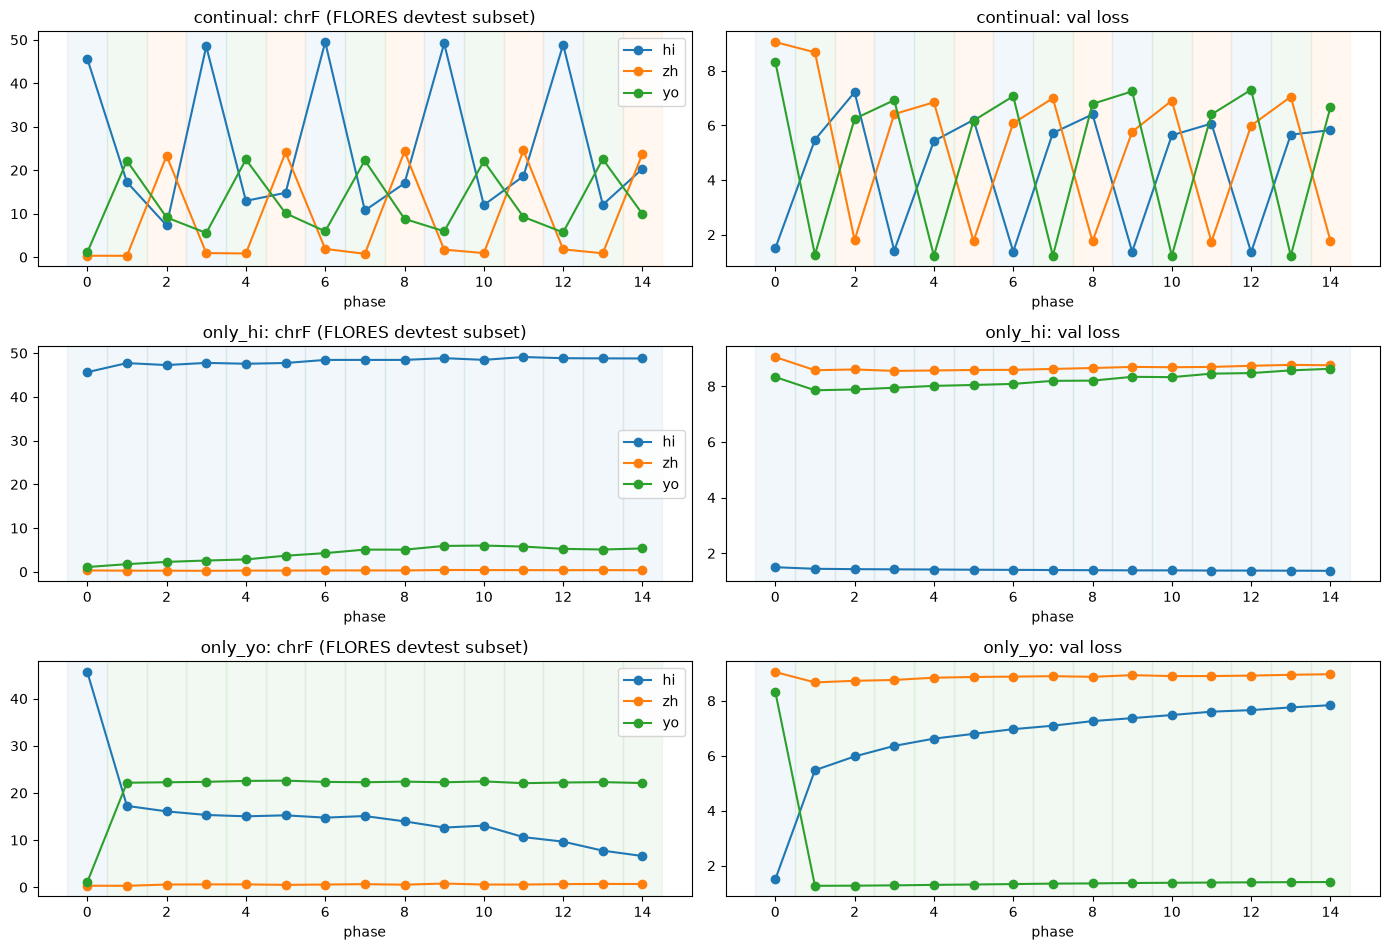

In [7]:

def read_phases(run):
    rows = {}
    for l in open(P("runs", run, "phases.jsonl")):
        r = json.loads(l); rows[r["phase"]] = r
    return [rows[k] for k in sorted(rows)]

fig, axes = plt.subplots(len(results), 2, figsize=(14, 3.2 * len(results)), squeeze=False)
for row, name in enumerate(results):
    ph = [r for r in read_phases(RUNS[name]) if not LIMIT or r["phase"] < LIMIT]
    x = [r["phase"] for r in ph]
    for l in LANGS:
        axes[row, 0].plot(x, [r["chrf_masked"][l] for r in ph], marker="o", label=l)
        axes[row, 1].plot(x, [r["val_masked"][l] for r in ph], marker="o", label=l)
    axes[row, 0].set_title(f"{name}: chrF (FLORES devtest subset)"); axes[row, 1].set_title(f"{name}: val loss")
    for ax in axes[row]:
        ax.set_xlabel("phase")
        for r in ph:                                   # shade by trained language
            ax.axvspan(r["phase"] - 0.5, r["phase"] + 0.5, alpha=0.06,
                       color={"hi": "C0", "zh": "C1", "yo": "C2"}[r["lang"]])
    axes[row, 0].legend()
plt.tight_layout(); plt.savefig(f"{OUT}/fig_training_curves.png", dpi=120); plt.show()

In [8]:
for name in results:
    ph = [r for r in read_phases(RUNS[name]) if not LIMIT or r["phase"] < LIMIT]
    tab = pd.DataFrame([{"phase": r["phase"], "trained": r["lang"], "steps": r["steps"], "stop": r["reason"],
                         **{f"chrF {l}": r["chrf_masked"][l] for l in LANGS},
                         **{f"val {l}": r["val_masked"][l] for l in LANGS}} for r in ph])
    print(name); display(tab)
    tab.to_csv(f"{OUT}/{name}_phases_0-{LIMIT - 1}.csv", index=False)

continual


,phase,trained,steps,stop,chrF hi,chrF zh,chrF yo,val hi,val zh,val yo
0,0,hi,0,init,45.65,0.32,1.09,1.4996,9.0502,8.3310
1,1,yo,14500,plateau,17.25,0.30,22.17,5.4767,8.6720,1.2680
2,2,zh,20000,plateau,7.29,23.32,9.13,7.2137,1.8080,6.2419
3,3,hi,19500,plateau,48.50,0.93,5.55,1.4209,6.4140,6.9242
4,4,yo,10500,plateau,12.95,0.84,22.48,5.4266,6.8457,1.2296
5,5,zh,13500,plateau,14.80,24.10,10.09,6.2006,1.7689,6.1754
6,6,hi,20000,plateau,49.50,1.89,5.93,1.3859,6.0796,7.0672
7,7,yo,10000,plateau,10.74,0.76,22.26,5.7195,6.9933,1.2290
8,8,zh,15500,plateau,16.99,24.32,8.80,6.4032,1.7549,6.7870
9,9,hi,16500,plateau,49.16,1.72,5.95,1.3802,5.7705,7.2454


only_hi


,phase,trained,steps,stop,chrF hi,chrF zh,chrF yo,val hi,val zh,val yo
0,0,hi,0,init,45.65,0.32,1.09,1.4996,9.0502,8.3310
1,1,hi,7500,plateau,47.72,0.26,1.75,1.4424,8.5761,7.8563
2,2,hi,6000,plateau,47.27,0.26,2.27,1.4297,8.6033,7.8838
3,3,hi,6000,plateau,47.77,0.23,2.58,1.4226,8.5516,7.9463
4,4,hi,6000,plateau,47.57,0.28,2.83,1.4168,8.5676,8.0134
5,5,hi,6000,plateau,47.74,0.28,3.68,1.4090,8.5849,8.0460
6,6,hi,6000,plateau,48.45,0.32,4.27,1.4040,8.5898,8.0844
7,7,hi,6000,plateau,48.45,0.32,5.08,1.3974,8.6222,8.1946
8,8,hi,6000,plateau,48.45,0.31,5.06,1.3922,8.6553,8.2022
9,9,hi,6000,plateau,48.85,0.42,5.92,1.3865,8.6949,8.3383


only_yo


,phase,trained,steps,stop,chrF hi,chrF zh,chrF yo,val hi,val zh,val yo
0,0,hi,0,init,45.65,0.32,1.09,1.4996,9.0502,8.3310
1,1,yo,14500,plateau,17.25,0.30,22.17,5.4767,8.6720,1.2680
2,2,yo,6000,plateau,16.09,0.57,22.26,5.9766,8.7303,1.2723
3,3,yo,6000,worsening,15.33,0.60,22.36,6.3616,8.7622,1.2845
4,4,yo,6000,worsening,15.04,0.60,22.55,6.6248,8.8430,1.3020
5,5,yo,6000,plateau,15.25,0.50,22.61,6.7991,8.8704,1.3155
6,6,yo,6000,plateau,14.76,0.57,22.34,6.9698,8.8827,1.3311
7,7,yo,6000,plateau,15.10,0.65,22.27,7.0961,8.8994,1.3478
8,8,yo,6000,plateau,13.97,0.54,22.40,7.2634,8.8751,1.3551
9,9,yo,6000,plateau,12.65,0.78,22.26,7.3717,8.9361,1.3702


## 6. Co-activation matrices at the latest checkpoint (blocks on the diagonal, as in the paper's Figure 3)

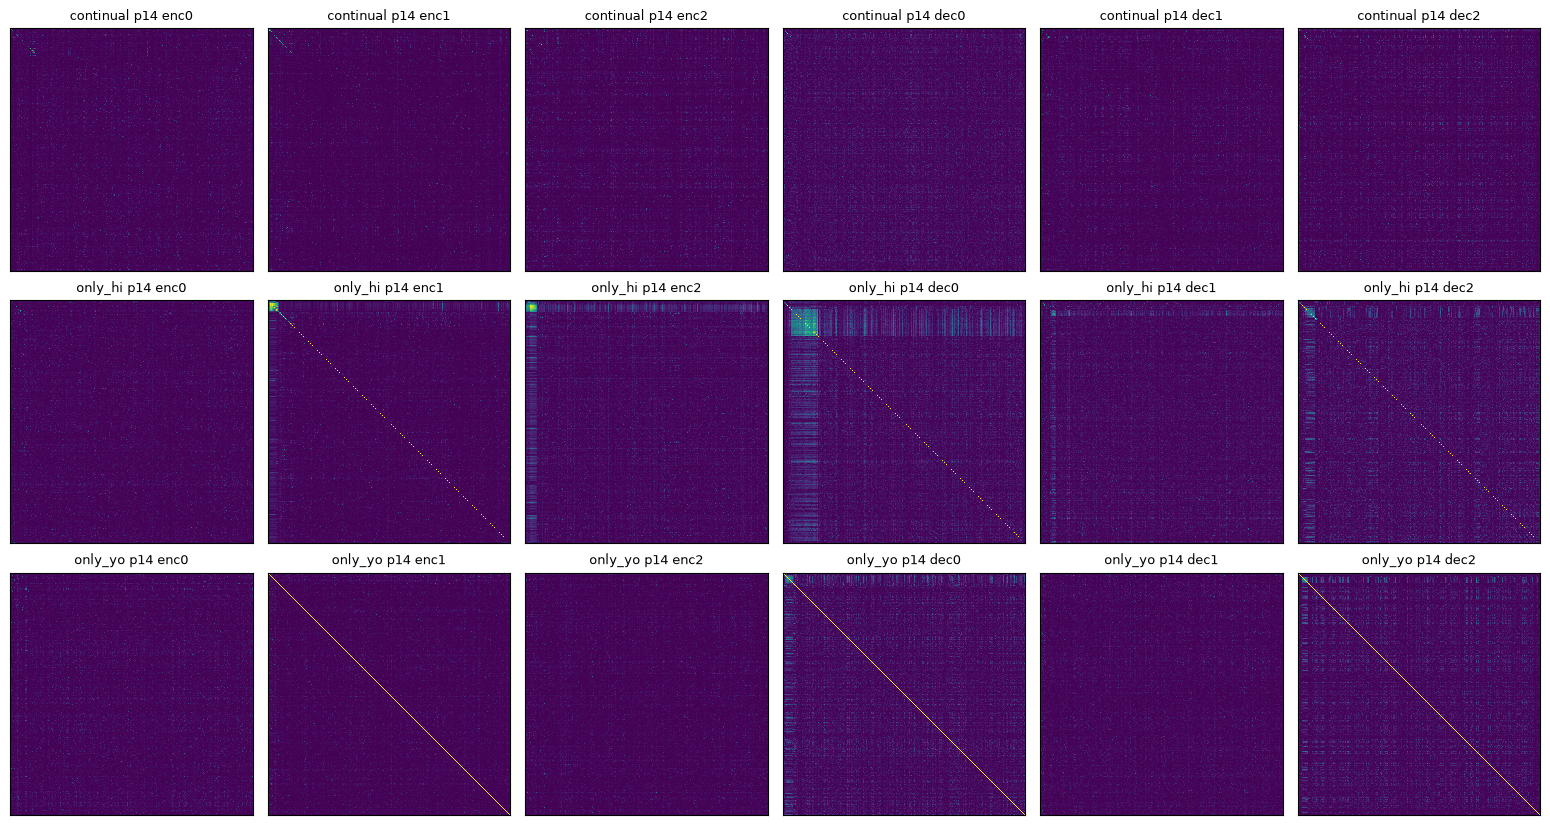

In [9]:
def plot_blocks(R, alive, tau, ax, title):
    idx = np.where(alive)[0]
    A = csr_matrix((np.abs(R[np.ix_(idx, idx)]) >= tau).astype(np.int8))
    order = idx[reverse_cuthill_mckee(A, symmetric_mode=True)]
    ax.imshow(np.abs(R[np.ix_(order, order)]), vmin=0, vmax=1, cmap="viridis", interpolation="nearest")
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(len(results), len(LAYERS), figsize=(2.6 * len(LAYERS), 2.8 * len(results)), squeeze=False)
for row, (name, r) in enumerate(results.items()):
    for col, l in enumerate(LAYERS):
        R, alive = r["last_R"][l]
        plot_blocks(R, alive, TAU_PLOT, axes[row, col], f"{name} p{r['last_phase']} {l}")
plt.tight_layout(); plt.savefig(f"{OUT}/fig_blocks_tau{TAU_PLOT}.png", dpi=120); plt.show()

## 7. Self-block size over phases

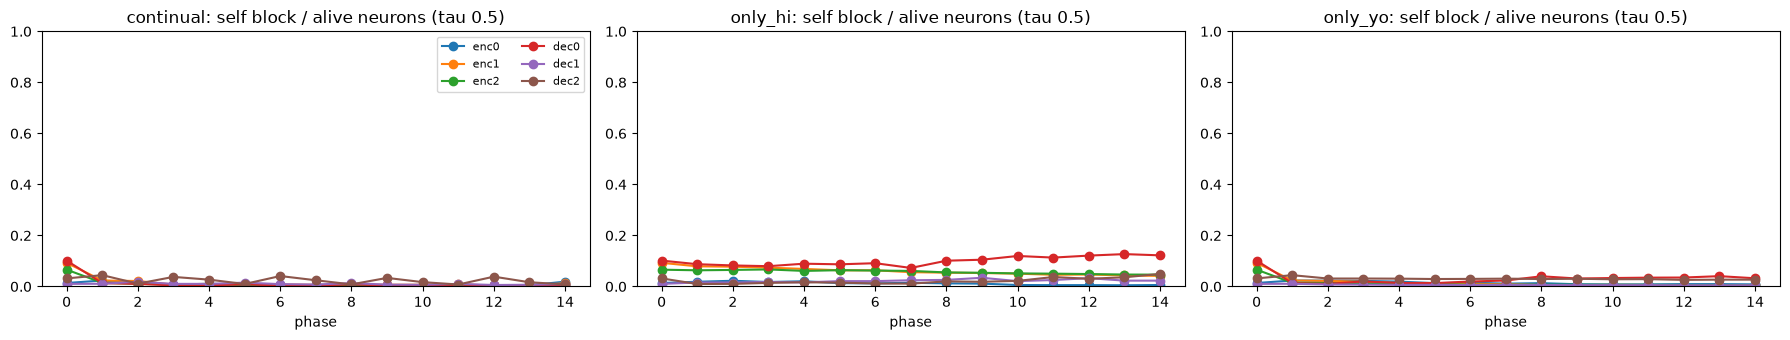

In [10]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 3.5), squeeze=False)
for ax, (name, r) in zip(axes[0], results.items()):
    B = r["blocks"][r["blocks"].tau == TAU_PLOT]
    for l in LAYERS:
        b = B[B.layer == l]
        ax.plot(b.phase, b.self_frac, marker="o", label=l)
    ax.set_ylim(0, 1); ax.set_title(f"{name}: self block / alive neurons (tau {TAU_PLOT})"); ax.set_xlabel("phase")
axes[0, 0].legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/fig_self_size_tau{TAU_PLOT}.png", dpi=120); plt.show()

## 8. Change at each switch: self vs task vs size-matched random (lower = more stable)

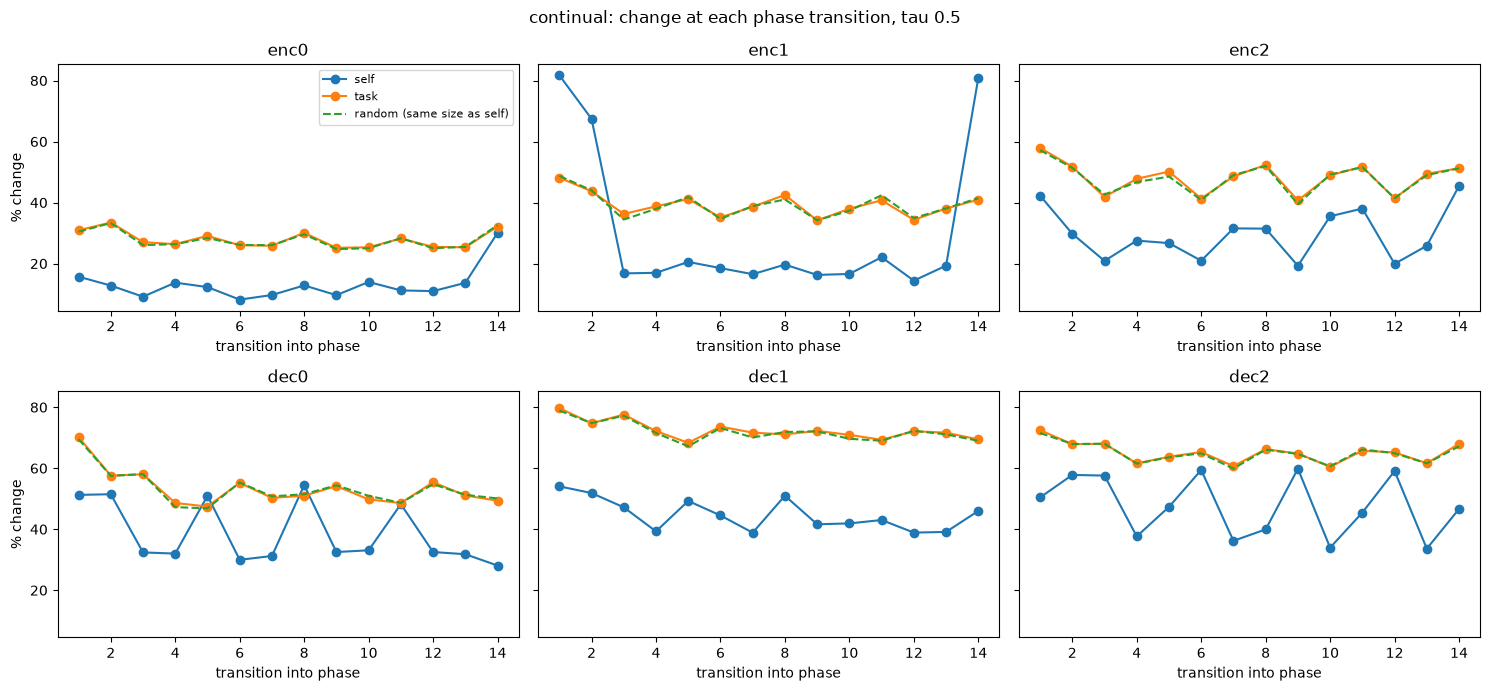

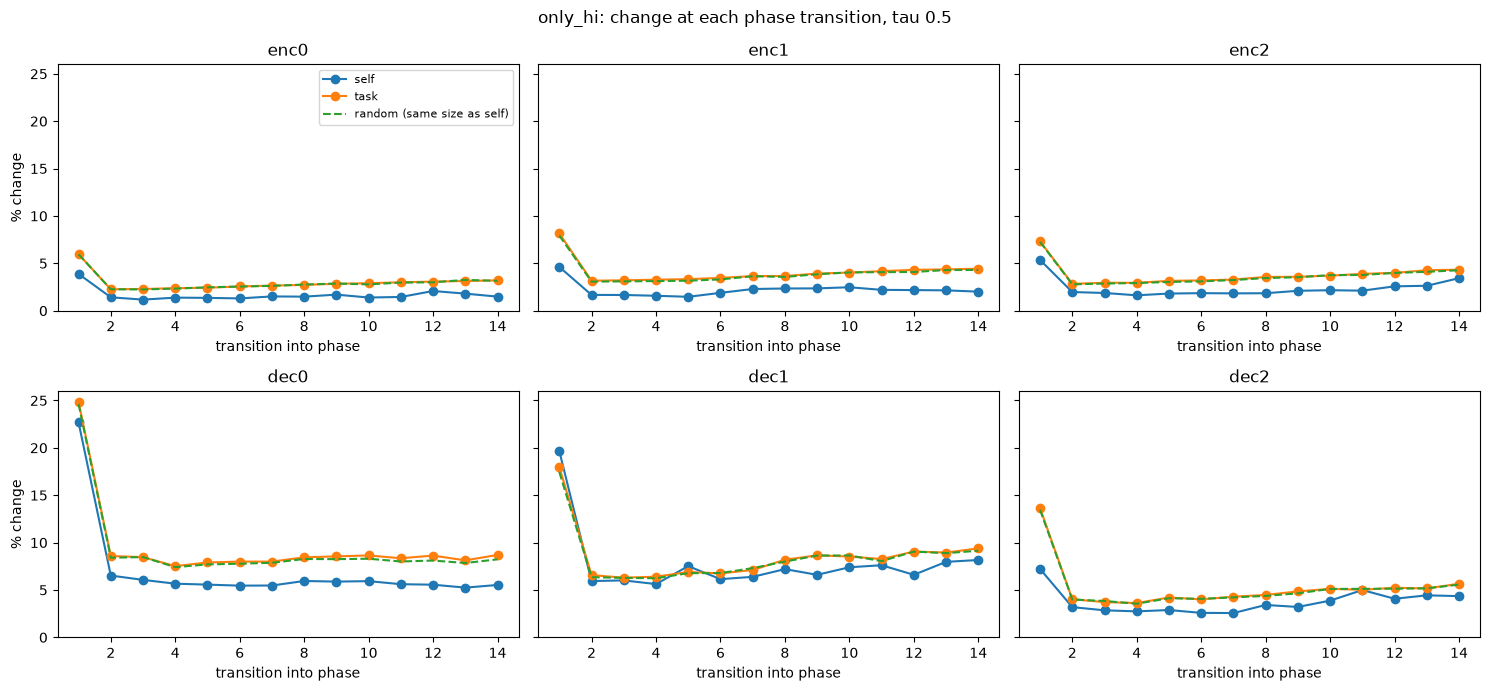

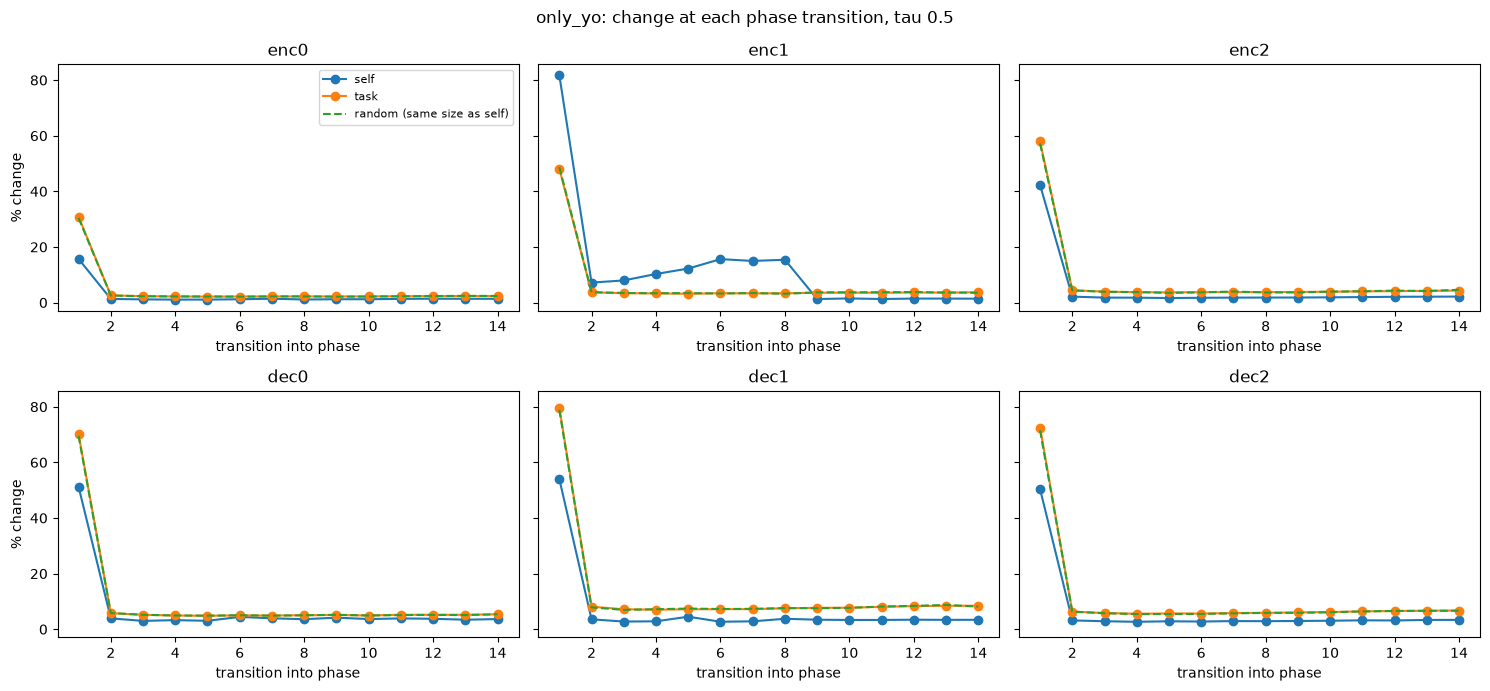

In [11]:
for name, r in results.items():
    T = r["trans"]
    if T.empty:
        print(f"{name}: needs at least 2 checkpoints for transitions"); continue
    T = T[T.tau == TAU_PLOT]
    fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
    for ax, l in zip(axes.flat, LAYERS):
        t = T[T.layer == l]
        ax.plot(t.to_phase, t.self_change, marker="o", label="self")
        ax.plot(t.to_phase, t.task_change, marker="o", label="task")
        ax.plot(t.to_phase, t.random_change, ls="--", label="random (same size as self)")
        ax.set_title(l); ax.set_xlabel("transition into phase")
    axes[0, 0].set_ylabel("% change"); axes[1, 0].set_ylabel("% change"); axes[0, 0].legend(fontsize=8)
    fig.suptitle(f"{name}: change at each phase transition, tau {TAU_PLOT}")
    plt.tight_layout(); plt.savefig(f"{OUT}/fig_change_{name}_tau{TAU_PLOT}.png", dpi=120); plt.show()

## 9. Summary: continual vs controls
`separation` = task change − self change (> 0: self more stable). `sep_vs_random` = random change − self change (> 0: self more stable than a random group of the same size). The paper's pattern: continual has a large self block AND positive separation; controls have neither.

In [12]:
rows = []
for name, r in results.items():
    T, B = r["trans"], r["blocks"]
    if T.empty:
        continue
    T = T[(T.tau == TAU_PLOT)]
    T = T[T.to_phase > T.to_phase.min() + SKIP_FIRST - 1] if SKIP_FIRST else T
    B = B[B.tau == TAU_PLOT]
    for l in LAYERS:
        t, b = T[T.layer == l], B[B.layer == l]
        rows.append({"run": name, "layer": l, "self_frac": b.self_frac.mean(),
                     "self_change": t.self_change.mean(), "task_change": t.task_change.mean(),
                     "random_change": t.random_change.mean(), "separation": t.separation.mean(),
                     "sep_vs_random": t.sep_vs_random.mean(),
                     "% transitions self more stable": 100 * (t.separation > 0).mean(),
                     "n_transitions": len(t)})
summary = pd.DataFrame(rows)
summary.to_csv(f"{OUT}/summary_tau{TAU_PLOT}.csv", index=False)
display(summary.round(2))
print(f"tables and figures saved in {OUT}")

,run,layer,self_frac,self_change,task_change,random_change,separation,sep_vs_random,% transitions self more stable,n_transitions
0,continual,enc0,0.01,13.14,27.89,27.68,14.75,14.54,100.00,14
1,continual,enc1,0.01,30.55,39.32,39.27,8.77,8.72,78.57,14
2,continual,enc2,0.01,29.65,48.23,47.87,18.58,18.22,100.00,14
3,continual,dec0,0.01,38.57,53.33,53.35,14.76,14.78,85.71,14
4,continual,dec1,0.01,44.76,72.48,72.00,27.72,27.24,100.00,14
5,continual,dec2,0.02,47.50,65.13,64.91,17.63,17.40,100.00,14
6,only_hi,enc0,0.01,1.67,2.96,2.94,1.29,1.27,100.00,14
7,only_hi,enc1,0.06,2.20,4.08,3.96,1.87,1.76,100.00,14
8,only_hi,enc2,0.06,2.37,3.78,3.72,1.42,1.35,100.00,14
9,only_hi,dec0,0.10,6.94,9.48,9.23,2.54,2.30,100.00,14


tables and figures saved in /workspace/shreshth/analysis/v3
